In [19]:
import numpy as np
import torch
from src.prc import KeyGen, Encode
import pickle
from inversion import stable_diffusion_pipe, generate
import src.pseudogaussians as prc_gaussians
from watermark_strategy import PRCWatermark

In [2]:
fpr = 0.00001
prc_t = 3
n = 4 * 64 * 64
model_id = 'stabilityai/stable-diffusion-2-1-base'

In [7]:
pipe = stable_diffusion_pipe(solver_order=1, model_id=model_id, cache_dir=".")
pipe.set_progress_bar_config(disable=True)

/home/ubuntu/miniconda3/envs/prc/lib/python3.11/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

In [8]:
wm = PRCWatermark()

In [9]:
init_latents = wm.get_init_latent()

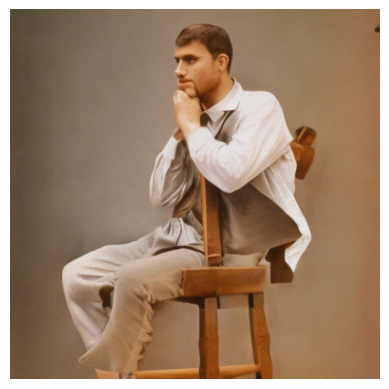

In [13]:
import matplotlib.pyplot as plt
current_prompt = "A young man sitting on a chair"
orig_image, _, _ = generate(prompt=current_prompt,
                            init_latents=init_latents,
                            num_inference_steps=50,
                            solver_order=1,
                            pipe=pipe
                            )
plt.imshow(orig_image)
plt.axis('off')
plt.show()

In [21]:
random_latents = torch.randn(1, 4, 64, 64).to('cuda:0')

In [22]:
wm.detect(random_latents.flatten().cpu())

6.35023221273933e-13

In [5]:
(encoding_key_ori, decoding_key_ori) = KeyGen(n, false_positive_rate=fpr, t=prc_t)

(GF([[1, 0, 1, ..., 1, 0, 0],
     [1, 1, 1, ..., 0, 1, 0],
     [0, 0, 1, ..., 0, 0, 1],
     ...,
     [1, 0, 1, ..., 0, 1, 1],
     [1, 1, 0, ..., 1, 1, 1],
     [1, 0, 1, ..., 1, 0, 0]], order=2),
 GF([1, 0, 1, ..., 0, 1, 1], order=2),
 GF([0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1], order=2),
 39,
 0.017615996328735894)

model_index.json:   0%|          | 0.00/543 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/807 [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/460 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

In [14]:
prc_codeword = Encode(encoding_key_ori)

In [18]:
init_latents = prc_gaussians.sample(prc_codeword).reshape(1, 4, 64, 64).to('cuda:0')
init_latents.shape

torch.Size([1, 4, 64, 64])

/home/ubuntu/miniconda3/envs/prc/lib/python3.11/site-packages/diffusers/pipelines/stable_diffusion/pipeline_stable_diffusion.py:430: FutureWarning: The decode_latents method is deprecated and will be removed in 1.0.0. Please use VaeImageProcessor.postprocess(...) instead
  deprecate("decode_latents", "1.0.0", deprecation_message, standard_warn=False)


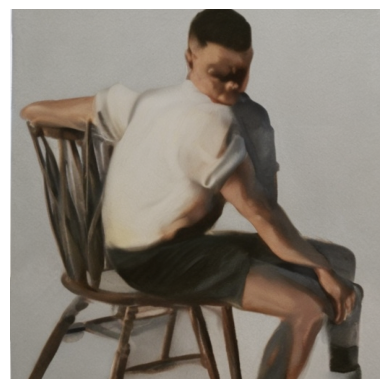

In [37]:
import torch
from src.prc import Detect, Decode
var = 1.5

In [36]:

reversed_prc = prc_gaussians.recover_posteriors(init_latents.to(torch.float64).flatten().cpu(), variances=float(var)).flatten().cpu()

In [38]:
detection_result = Detect(decoding_key_ori, reversed_prc)
detection_result

True

In [40]:
Decode(decoding_key_ori, reversed_prc)

array([0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,